In [39]:
import cv2
import numpy as np
import os

def preprocess_video(video_path, target_frames=16, target_size=(224, 224)):
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Cannot open video {video_path}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return None

    # Temporal Sampling Indices
    indices = np.linspace(0, total_frames - 1, num=target_frames, dtype=int)
    
    # Initialize CLAHE (Contrast Limited Adaptive Histogram Equalization) for CCTV enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    video_sequence = []
    current_frame_idx = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        if current_frame_idx in indices:
            # Handle multiple indices matches (padding for ultra-short clips)
            occurrences = np.sum(indices == current_frame_idx)
            for _ in range(occurrences):
                
                # --- A. SPATIAL PROCESSING & ASPECT RATIO ---
                # Letterbox/Resize preserving aspect ratio to avoid squishing human figures
                h, w = frame.shape[:2]
                t_w, t_h = target_size
                scale = min(t_w / w, t_h / h)
                nw, nh = int(w * scale), int(h * scale)
                
                resized = cv2.resize(frame, (nw, nh), interpolation=cv2.INTER_AREA)
                
                # Create canvas and paste the resized image in the center
                canvas = np.zeros((t_h, t_w, 3), dtype=np.uint8)
                dx, dy = (t_w - nw) // 2, (t_h - nh) // 2
                canvas[dy:dy+nh, dx:dx+nw] = resized
                
                # --- B. QUALITY & CONTRAST ENHANCEMENT ---
                # Convert to YCrCb to enhance luminosity channel without messing up colors
                ycrcb = cv2.cvtColor(canvas, cv2.COLOR_BGR2YCrCb)
                ycrcb[:, :, 0] = clahe.apply(ycrcb[:, :, 0])
                enhanced = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB) # Switch to RGB for Deep Learning
                
                # Mild Bilateral Filter: Denoises low-quality video but *keeps sharp edges* of moving bodies
                filtered = cv2.bilateralFilter(enhanced, d=5, sigmaColor=35, sigmaSpace=35)
                
                # --- C. NORMALIZATION ---
                normalized = filtered.astype(np.float32) / 255.0
                video_sequence.append(normalized)
                
        current_frame_idx += 1
        if len(video_sequence) >= target_frames:
            break

    cap.release()
    
    # Ensure we strictly return the expected shape
    video_tensor = np.array(video_sequence)[:target_frames]
    return video_tensor
"""
# Quick Verification
if __name__ == "__main__":
    # Test with a dummy or real video path
    sample_path = r"D:\downloads\Movies\Robbery150_x264.mp4"
    if os.path.exists(sample_path):
        tensor = preprocess_video_ultimate(sample_path, target_frames=16, target_size=(224, 224))
        print(f"Tensor shape: {tensor.shape}")
"""

'\n# Quick Verification\nif __name__ == "__main__":\n    # Test with a dummy or real video path\n    sample_path = r"D:\\downloads\\Movies\\Robbery150_x264.mp4"\n    if os.path.exists(sample_path):\n        tensor = preprocess_video_ultimate(sample_path, target_frames=16, target_size=(224, 224))\n        print(f"Tensor shape: {tensor.shape}")\n'

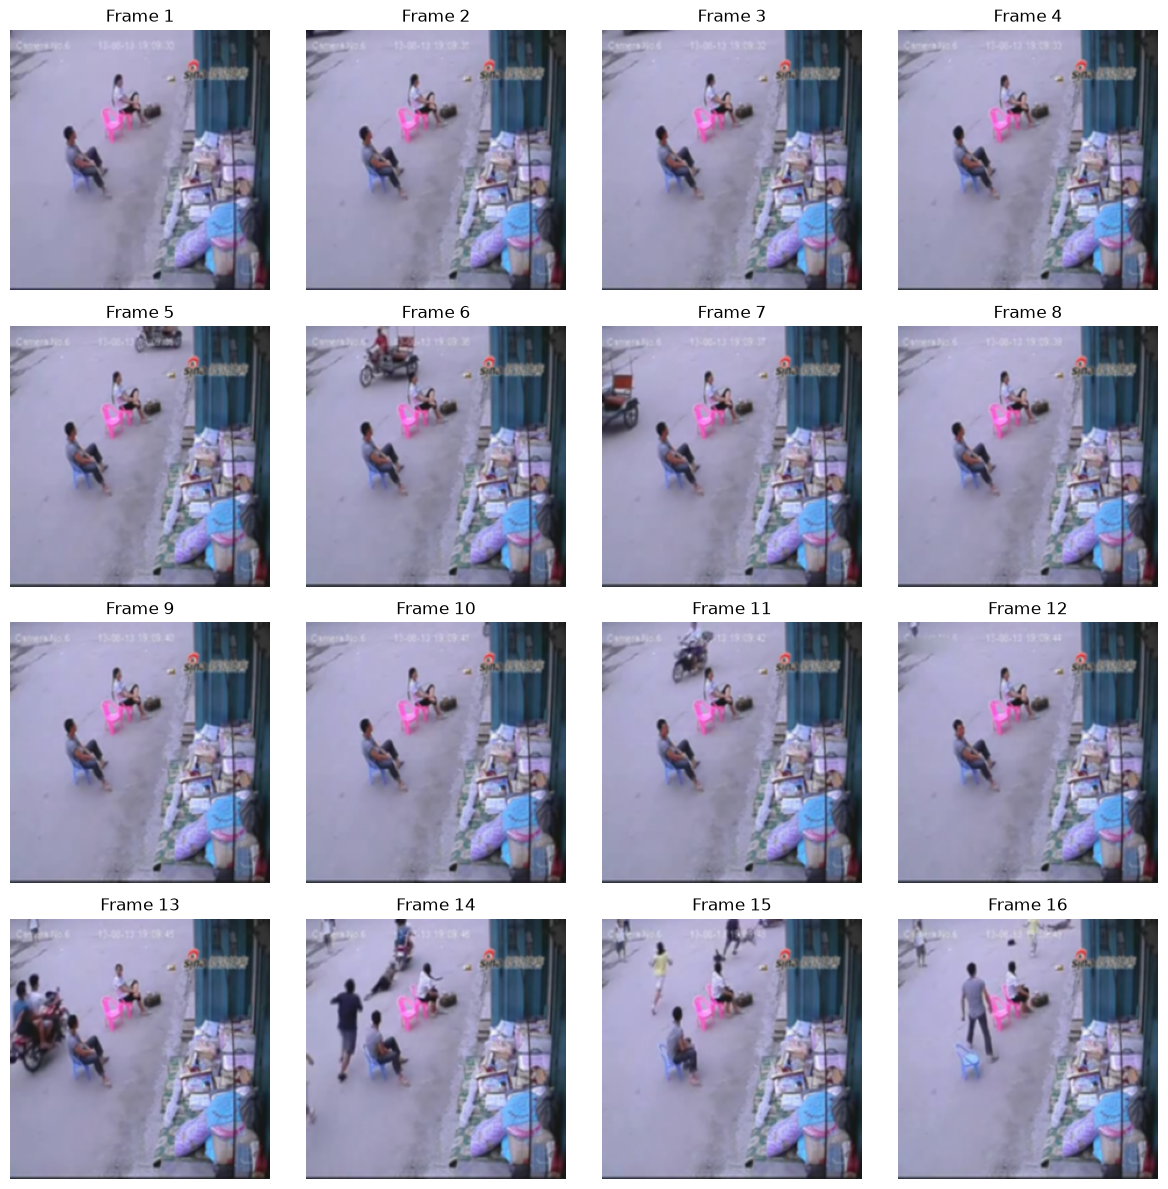

In [35]:
import matplotlib.pyplot as plt

def visualize_frame_sequence(processed_tensor):
    """
    Plots the processed video tensor frames in a grid.
    Input shape: (num_frames, height, width, channels)
    """
    num_frames = processed_tensor.shape[0]
    
    # Create a grid dynamically based on frame count
    cols = 4
    rows = (num_frames + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))
    axes = axes.flatten()
    
    for i in range(num_frames):
        # Matplotlib expects RGB [0, 1] for floats, OpenCV outputs BGR
        # Flip BGR to RGB for correct colors
        frame_rgb = cv2.cvtColor((processed_tensor[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Frame {i+1}")
        axes[i].axis('off')
        
    # Hide unused subplots
    for j in range(num_frames, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Usage:
visualize_frame_sequence(processed_data)

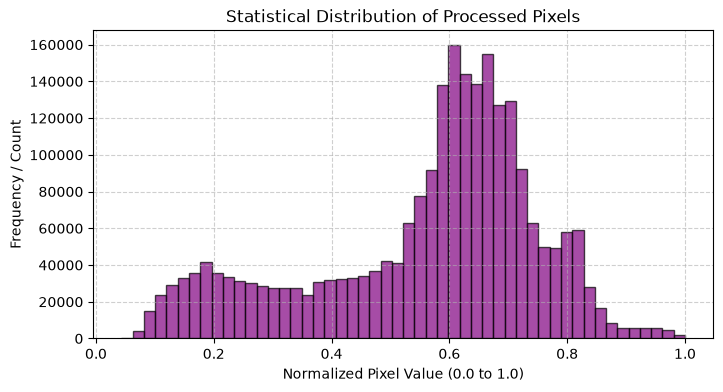

In [41]:
def plot_pixel_distribution(processed_tensor):
    """
    Plots a histogram showing the distribution of pixel values across all frames.
    """
    # Flatten the tensor to 1D array of pixel values
    pixels = processed_tensor.flatten()
    
    plt.figure(figsize=(8, 4))
    plt.hist(pixels, bins=50, color='purple', alpha=0.7, edgecolor='black')
    plt.title("Statistical Distribution of Processed Pixels")
    plt.xlabel("Normalized Pixel Value (0.0 to 1.0)")
    plt.ylabel("Frequency / Count")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
plot_pixel_distribution(processed_data)

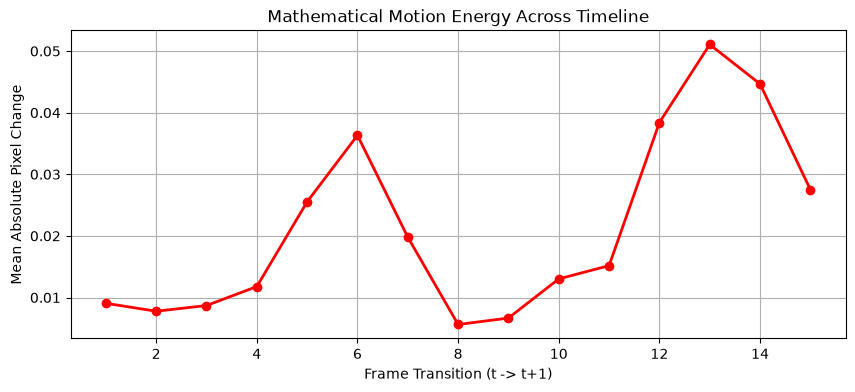

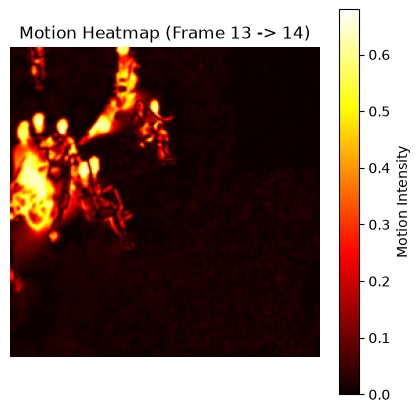

In [42]:
def plot_motion_energy(processed_tensor):
    """
    Calculates and plots the mathematical motion energy between frames.
    """
    num_frames = processed_tensor.shape[0]
    motion_signals = []
    
    # Calculate the average absolute difference between consecutive frames
    for i in range(num_frames - 1):
        diff = np.abs(processed_tensor[i+1] - processed_tensor[i])
        mean_diff = np.mean(diff)
        motion_signals.append(mean_diff)
        
    # 1. Line Plot of Motion over Time
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, num_frames), motion_signals, marker='o', color='red', linewidth=2)
    plt.title("Mathematical Motion Energy Across Timeline")
    plt.xlabel("Frame Transition (t -> t+1)")
    plt.ylabel("Mean Absolute Pixel Change")
    plt.grid(True)
    plt.show()
    
    # 2. Visual Heatmap of the highest motion transition
    max_motion_idx = np.argmax(motion_signals)
    highest_diff = np.abs(processed_tensor[max_motion_idx+1] - processed_tensor[max_motion_idx])
    # Convert to grayscale to get a single intensity map
    heatmap = np.mean(highest_diff, axis=-1) 
    
    plt.figure(figsize=(5, 5))
    plt.imshow(heatmap, cmap='hot')
    plt.title(f"Motion Heatmap (Frame {max_motion_idx+1} -> {max_motion_idx+2})")
    plt.colorbar(label="Motion Intensity")
    plt.axis('off')
    plt.show()

plot_motion_energy(processed_data)


In [ ]:
import cv2
import numpy as np
import time

def play_processed_video_with_motion_tracking(processed_tensor, fps=8):
  
    print("\nPress 'q' in the pop-up video window to stop playback.")
    num_frames = processed_tensor.shape[0]
    delay = 1.0 / fps # Control playback speed
    
    #to stay looping until user presses q
    while True:
        for i in range(num_frames):
            # 1. Get the current frame and prepare it for display
            # Convert float32 back to uint8 [0-255] for OpenCV rendering
            frame = (processed_tensor[i] * 255).astype(np.uint8)
            display_frame = frame.copy()
            
            # 2. Extract Motion (Compare with next frame if available)
            if i < num_frames - 1:
                next_frame = (processed_tensor[i+1] * 255).astype(np.uint8)
                
                # Convert both to grayscale to track changes
                gray1 = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                gray2 = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
                
                # Calculate absolute difference between the two frames
                frame_delta = cv2.absdiff(gray1, gray2)
                
                # Threshold the difference map to completely isolate significant movement
                _, thresh = cv2.threshold(frame_delta, 15, 255, cv2.THRESH_BINARY)
                
                # Dilate the thresholded image to fill in gaps in the motion block
                thresh = cv2.dilate(thresh, None, iterations=2)
                
                # Find contours (edges) of the moving regions
                contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                # 3. Draw bounding boxes around the motion zones (e.g., flying punches/kicks)
                for contour in contours:
                    # Ignore tiny movements (noise) by filtering by area size
                    if cv2.contourArea(contour) < 150: 
                        continue
                        
                    (x, y, w, h) = cv2.boundingRect(contour)
                    # Draw a red rectangle over the motion area
                    cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
                    cv2.putText(display_frame, "ACTION DETECTED", (x, max(15, y - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

            # 4. Display the results
            cv2.imshow("Preprocessed Video Stream (Motion Tracking)", display_frame)
            time.sleep(delay)
            
            # Break loop instantly if user presses 'q'
            if cv2.waitKey(1) & 0xFF == ord('q'):
                cv2.destroyAllWindows()
                print("Video player closed.")
                return

#for testing
#play_processed_video_with_motion_tracking(processed_data, fps=4)


🎬 Press 'q' in the pop-up video window to stop playback.
Video player closed.
